# CGPA Prediction Model — Complete Evaluation Report
**Model:** StackingRegressor (Ridge + RF + ExtraTrees + GradientBoosting + XGBoost + LightGBM + KNN)  
**Dataset:** 961 students (581 valid CGPA + 380 imputed via MICE)  
**Features:** 20 (18 original + intro_grade + hw_grade)  
**KFold:** 10 splits, shuffle=True, random_state=42

In [1]:
# ══════════════════════════════════════════════════════════════
# SETUP: Replicate exact pipeline from cgpa_prediction_v2.py
# ══════════════════════════════════════════════════════════════
import warnings, re, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── EXACT SAME PARSERS from cgpa_prediction_v2.py ──
REJECT_WORDS = [
    'na','n/a','none','null','not','reappear','re-appear','reaper','back',
    'fail','supply','pending','got','know','sure','declared','yet',
    'available','received','first','1st','one','unknown','no','fresher',
    '4 sem','1year','awaited','yta','result'
]
def is_reject(s): return any(w in s for w in REJECT_WORDS)

def extract_gpa(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if is_reject(s): return np.nan
    s = re.sub(r'sgpa|cgpa|grade|/10|out of 10', '', s)
    m = re.match(r'([\.\d]+)\s*/\s*10', s)
    if m: return float(m.group(1))
    nums = re.findall(r'[\d]+\.?[\d]*', s)
    if not nums: return np.nan
    v = float(nums[0])
    return v if 0 < v <= 10 else np.nan

def extract_score(val, lo=0, hi=100):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if is_reject(s): return np.nan
    nums = re.findall(r'[\d]+\.?[\d]*', s)
    if not nums: return np.nan
    vals = [float(x) for x in nums if lo <= float(x) <= hi]
    return np.mean(vals) if vals else np.nan

def extract_pct(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    reject_pct = ['na','n/a','none','not','sure','know','covid','pass','a grade','a+','idk','-','.']
    if any(r == s or r in s.split() for r in reject_pct): return np.nan
    s = re.sub(r'percent|%', '', s)
    nums = re.findall(r'[\d]+\.?[\d]*', s)
    if not nums: return np.nan
    v = float(nums[0])
    if v > 100: return np.nan
    if v <= 1: v *= 100
    return v if 0 <= v <= 100 else np.nan

def extract_hours(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if any(r in s for r in ['na','fix','nothing','depends','all day']): return np.nan
    nums = [float(x) for x in re.findall(r'[\d]+\.?[\d]*', s) if float(x) <= 24]
    return np.mean(nums) if nums else np.nan

def extract_backlogs(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if any(x in s for x in ['no','nil','none','zero','na','null','nill','-','0 backlogs']): return 0.0
    nums = re.findall(r'[\d]+', s)
    return float(nums[0]) if nums else np.nan

def extract_dist(val):
    if pd.isna(val): return np.nan
    s = str(val).strip().lower()
    if any(r in s for r in ['na','hostel','walk','accommodation']): return np.nan
    if 'meter' in s:
        nm = re.findall(r'[\d]+\.?[\d]*', s)
        return float(nm[0]) / 1000 if nm else np.nan
    nums = [float(x) for x in re.findall(r'[\d]+\.?[\d]*', s) if float(x) < 1000]
    return np.mean(nums) if nums else np.nan

def encode_complexity(val):
    if pd.isna(val): return np.nan
    s = str(val).lower()
    if '1' in s or 'easy' in s: return 1
    if '2' in s or 'medium' in s: return 2
    if '3' in s or 'hard' in s: return 3
    return np.nan

def encode_teacher_fb(val):
    if pd.isna(val): return np.nan
    s = str(val).lower()
    if 'good' in s and 'not' not in s: return 3
    if 'confident' in s or 'need' in s: return 2
    return 1

def encode_participation(val):
    if pd.isna(val): return np.nan
    s = str(val).lower()
    if 'moderator' in s: return 4
    if 'shares' in s or 'brings' in s or 'statistic' in s: return 3
    if 'listener' in s: return 2
    if 'less active' in s: return 1
    return 2

print('Parsers loaded successfully.')

Parsers loaded successfully.


In [2]:
# ══════════════════════════════════════════════════════════════
# DATA LOADING + PARSING + MICE + FEATURE ENGINEERING
# (100% identical to cgpa_prediction_v2.py)
# ══════════════════════════════════════════════════════════════
BASE = os.path.join(os.path.dirname(os.path.abspath('.')), 'Code Playground', 'cgpa_predict', 'CGPA Project')
if not os.path.exists(BASE):
    BASE = 'CGPA Project'

df_raw = pd.read_csv(os.path.join(BASE, 'original_data.csv'))
print(f'Raw shape: {df_raw.shape}')

df = pd.DataFrame()
df['midterm']     = df_raw['Midterm_Score_Average'].apply(extract_score)
df['assign']      = df_raw['Assignment_Score_Average'].apply(extract_score)
df['twelfth_pct'] = df_raw['Twelfth_Grade_Percentage'].apply(extract_pct)
df['tenth_pct']   = df_raw['Tenth_Grade_Percentage'].apply(extract_pct)
df['study_hours'] = df_raw['Study_Hours_Per_Day'].apply(extract_hours)
df['attendance']  = df_raw['Attendance_Percentage'].apply(extract_pct)
df['backlogs']    = df_raw['Number_of_Backlogs'].apply(extract_backlogs)
df['stress']      = df_raw['Mental_Stress_Score'].astype(str).str.strip().map({'0': 0, '1': 1}).astype(float)
df['distance']    = df_raw['Distance_From_Campus_KM'].apply(extract_dist)
df['complexity']  = df_raw.iloc[:, 14].apply(encode_complexity)
df['teacher_fb']  = df_raw.iloc[:, 15].apply(encode_teacher_fb)
df['participation'] = df_raw.iloc[:, 16].apply(encode_participation)
df['prev_prev_gpa'] = df_raw['CGPA of last to last Semester'].apply(extract_gpa)
df['CGPA']        = df_raw['Previous_Semester_GPA'].apply(extract_gpa)

print(f'After parsing: {df.shape}')
print(f'  CGPA valid: {df["CGPA"].notna().sum()}, missing: {df["CGPA"].isna().sum()}')

# MICE Imputation
feature_cols = ['midterm', 'assign', 'twelfth_pct', 'tenth_pct', 'study_hours',
                'attendance', 'backlogs', 'stress', 'distance', 'complexity',
                'teacher_fb', 'participation', 'prev_prev_gpa']

feat_imputer = SimpleImputer(strategy='median')
df[feature_cols] = feat_imputer.fit_transform(df[feature_cols])

all_cols = feature_cols + ['CGPA']
mice_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=42, verbose=0)
df_imputed = pd.DataFrame(mice_imputer.fit_transform(df[all_cols]), columns=all_cols)
df_imputed['CGPA'] = df_imputed['CGPA'].clip(0, 10)
original_valid_mask = df['CGPA'].notna()
df[all_cols] = df_imputed[all_cols]

# Feature Engineering
df['midterm_norm']    = df['midterm'].clip(0, 100)
df['assign_norm']     = df['assign'].clip(0, 100)
df['academic_score']  = (df['midterm_norm'] + df['assign_norm']) / 2
df['school_avg']      = (df['twelfth_pct'] + df['tenth_pct']) / 2
df['attend_stress']   = df['attendance'] * (1 - df['stress'] * 0.1)
df['backlogs_log']    = np.log1p(df['backlogs'])
df['has_prev_gpa']    = original_valid_mask.astype(int)

# Intro + HW grades
intro_df = pd.read_csv(os.path.join(BASE, 'data', 'intro_grades.csv'))
intro_map = dict(zip(intro_df['row_idx'], intro_df['intro_grade']))
df['intro_grade'] = [intro_map.get(i, np.nan) for i in range(len(df))]

hw_df = pd.read_csv(os.path.join(BASE, 'data', 'handwriting_grades.csv'))
hw_map = dict(zip(hw_df['row_idx'], hw_df['hw_grade']))
df['hw_grade'] = [hw_map.get(i, np.nan) for i in range(len(df))]

FEATURES = [
    'midterm_norm', 'assign_norm', 'twelfth_pct', 'tenth_pct',
    'study_hours', 'attendance', 'backlogs', 'stress', 'distance',
    'complexity', 'teacher_fb', 'participation', 'prev_prev_gpa',
    'academic_score', 'school_avg', 'attend_stress', 'backlogs_log',
    'has_prev_gpa', 'intro_grade', 'hw_grade',
]

X = df[FEATURES]
y = df['CGPA']
model = joblib.load(os.path.join(BASE, 'best_cgpa_model_v2.pkl'))

print(f'\nX shape: {X.shape}, y shape: {y.shape}')
print(f'Features: {len(FEATURES)}')
print('\nData pipeline replicated successfully!')

Raw shape: (961, 21)
After parsing: (961, 14)
  CGPA valid: 581, missing: 380

X shape: (961, 20), y shape: (961,)
Features: 20

Data pipeline replicated successfully!


In [3]:
# ══════════════════════════════════════════════════════════════
# HELPER: Convert continuous CGPA to grade categories
# for computing Precision, Recall, F1, Confusion Matrix
# ══════════════════════════════════════════════════════════════

GRADE_BINS   = [0, 5, 6, 7, 8, 9, 10.01]
GRADE_LABELS = ['Below 5', '5-6', '6-7', '7-8', '8-9', '9-10']

def to_grade(vals):
    return pd.cut(vals, bins=GRADE_BINS, labels=GRADE_LABELS, right=False)

def compute_all_metrics(y_true, y_pred, label=''):
    """Compute both regression + classification metrics."""
    # Regression
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    a05  = np.mean(np.abs(y_pred - y_true) <= 0.5) * 100
    a10  = np.mean(np.abs(y_pred - y_true) <= 1.0) * 100
    
    # Classification (grade-level)
    g_true = to_grade(y_true)
    g_pred = to_grade(np.clip(y_pred, 0, 10))
    
    precision = precision_score(g_true, g_pred, average='weighted', zero_division=0)
    recall    = recall_score(g_true, g_pred, average='weighted', zero_division=0)
    f1        = f1_score(g_true, g_pred, average='weighted', zero_division=0)
    cm        = confusion_matrix(g_true, g_pred, labels=GRADE_LABELS)
    
    return {
        'label': label,
        'mae': round(mae, 4), 'rmse': round(rmse, 4), 'r2': round(r2, 4),
        'acc_05': round(a05, 1), 'acc_10': round(a10, 1),
        'precision': round(precision, 4), 'recall': round(recall, 4), 'f1': round(f1, 4),
        'cm': cm, 'g_true': g_true, 'g_pred': g_pred,
        'y_true': y_true, 'y_pred': y_pred
    }

print('Helper functions ready.')

Helper functions ready.


In [4]:
# ══════════════════════════════════════════════════════════════
# RUN 10-FOLD CV + COLLECT ALL PREDICTIONS
# ══════════════════════════════════════════════════════════════
kf = KFold(n_splits=10, shuffle=True, random_state=42)

all_fold_metrics = []
all_cv_y_true = []
all_cv_y_pred = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_val), 0, 10)
    
    m = compute_all_metrics(y_val.values, preds, label=f'Fold {fold_idx+1}')
    m['fold'] = fold_idx + 1
    m['train_size'] = len(train_idx)
    m['val_size'] = len(val_idx)
    all_fold_metrics.append(m)
    
    all_cv_y_true.extend(y_val.values)
    all_cv_y_pred.extend(preds)

all_cv_y_true = np.array(all_cv_y_true)
all_cv_y_pred = np.array(all_cv_y_pred)

# Identify max accuracy fold
max_fold = max(all_fold_metrics, key=lambda x: x['acc_10'])

# Compute aggregated CV metrics (all predictions pooled)
cv_agg = compute_all_metrics(all_cv_y_true, all_cv_y_pred, label='CV Aggregated (All Folds)')

# Compute holdout (80/20)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X, y, test_size=0.20, random_state=42)
model.fit(X_train_h, y_train_h)
preds_h = np.clip(model.predict(X_test_h), 0, 10)
holdout = compute_all_metrics(y_test_h.values, preds_h, label='Holdout (80/20 Split)')
holdout['train_size'] = len(X_train_h)
holdout['val_size'] = len(X_test_h)

print('All evaluations complete!')

All evaluations complete!


---
## 1. Per-Fold Results Table

In [5]:
rows = []
for m in all_fold_metrics:
    rows.append({
        'Fold': m['fold'],
        'Split': '90/10',
        'Train': m['train_size'],
        'Val': m['val_size'],
        'R\u00b2': m['r2'],
        'MAE': m['mae'],
        'RMSE': m['rmse'],
        'Acc \u00b10.5': f"{m['acc_05']}%",
        'Acc \u00b11.0': f"{m['acc_10']}%",
        'Precision': m['precision'],
        'Recall': m['recall'],
        'F1 Score': m['f1'],
    })

fold_table = pd.DataFrame(rows)
fold_table

,Fold,Split,Train,Val,R²,MAE,RMSE,Acc ±0.5,Acc ±1.0,Precision,Recall,F1 Score
0,1,90/10,864,97,0.5421,0.3131,0.4912,76.3%,95.9%,0.7602,0.7423,0.7373
1,2,90/10,865,96,0.8506,0.2911,0.5040,82.3%,91.7%,0.6985,0.7083,0.6926
2,3,90/10,865,96,0.7284,0.2858,0.5401,84.4%,95.8%,0.7279,0.7083,0.7049
3,4,90/10,865,96,0.6340,0.3228,0.5579,82.3%,94.8%,0.6337,0.6458,0.6358
4,5,90/10,865,96,0.8612,0.2834,0.4282,83.3%,95.8%,0.7013,0.6875,0.6848
5,6,90/10,865,96,0.8648,0.2414,0.3708,88.5%,96.9%,0.7852,0.7500,0.7508
6,7,90/10,865,96,0.7365,0.2913,0.4441,79.2%,95.8%,0.6893,0.6979,0.6872
7,8,90/10,865,96,0.7342,0.2306,0.4150,83.3%,93.8%,0.7657,0.7604,0.7604
8,9,90/10,865,96,0.5285,0.3079,0.6315,83.3%,95.8%,0.7182,0.6875,0.6922
9,10,90/10,865,96,0.6781,0.3433,0.5679,78.1%,91.7%,0.6826,0.6667,0.6633


---
## 2. Metrics at MAXIMUM Accuracy (Best Fold)

In [6]:
print('=' * 65)
print(f'BEST FOLD: Fold {max_fold["fold"]} (Maximum Accuracy)')
print('=' * 65)
print(f'  Split Ratio         : 90% Train / 10% Validation')
print(f'  Training Set Size   : {max_fold["train_size"]} students')
print(f'  Validation Set Size : {max_fold["val_size"]} students')
print(f'  ---')
print(f'  R\u00b2 (R-Squared)      : {max_fold["r2"]}')
print(f'  MAE                 : {max_fold["mae"]}')
print(f'  RMSE                : {max_fold["rmse"]}')
print(f'  Accuracy (\u00b10.5)     : {max_fold["acc_05"]}%')
print(f'  Accuracy (\u00b11.0)     : {max_fold["acc_10"]}%')
print(f'  ---')
print(f'  Precision (weighted): {max_fold["precision"]}')
print(f'  Recall (weighted)   : {max_fold["recall"]}')
print(f'  F1 Score (weighted) : {max_fold["f1"]}')

BEST FOLD: Fold 6 (Maximum Accuracy)
  Split Ratio         : 90% Train / 10% Validation
  Training Set Size   : 865 students
  Validation Set Size : 96 students
  ---
  R² (R-Squared)      : 0.8648
  MAE                 : 0.2414
  RMSE                : 0.3708
  Accuracy (±0.5)     : 88.5%
  Accuracy (±1.0)     : 96.9%
  ---
  Precision (weighted): 0.7852
  Recall (weighted)   : 0.75
  F1 Score (weighted) : 0.7508


Confusion Matrix — Fold 6 (Max Accuracy = 96.9%)



,Pred: Below 5,Pred: 5-6,Pred: 6-7,Pred: 7-8,Pred: 8-9,Pred: 9-10
True: Below 5,2,0,0,0,0,0
True: 5-6,0,2,0,0,0,0
True: 6-7,0,0,13,1,0,0
True: 7-8,0,1,11,44,2,0
True: 8-9,0,0,0,6,9,0
True: 9-10,0,0,0,1,2,2


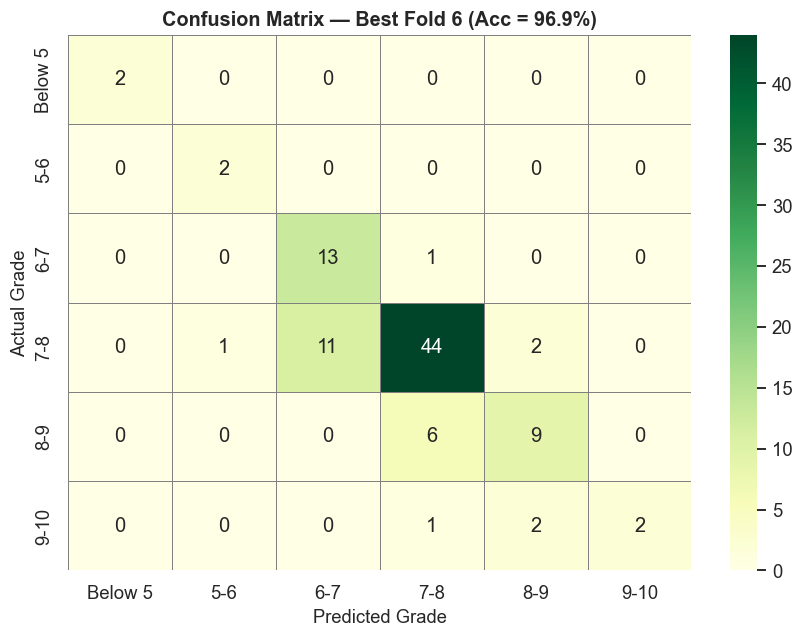


Per-Class Classification Report:
              precision    recall  f1-score   support

     Below 5       1.00      1.00      1.00         2
         5-6       0.67      1.00      0.80         2
         6-7       0.54      0.93      0.68        14
         7-8       0.85      0.76      0.80        58
         8-9       0.69      0.60      0.64        15
        9-10       1.00      0.40      0.57         5

    accuracy                           0.75        96
   macro avg       0.79      0.78      0.75        96
weighted avg       0.79      0.75      0.75        96



In [7]:
# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX — BEST FOLD (Maximum Accuracy)
# ══════════════════════════════════════════════════════════════
cm_df = pd.DataFrame(
    max_fold['cm'],
    index=[f'True: {l}' for l in GRADE_LABELS],
    columns=[f'Pred: {l}' for l in GRADE_LABELS]
)
print(f'Confusion Matrix — Fold {max_fold["fold"]} (Max Accuracy = {max_fold["acc_10"]}%)')
print()
display(cm_df)

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(max_fold['cm'], annot=True, fmt='d', cmap='YlGn',
            xticklabels=GRADE_LABELS, yticklabels=GRADE_LABELS, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted Grade', fontsize=12)
ax.set_ylabel('Actual Grade', fontsize=12)
ax.set_title(f'Confusion Matrix — Best Fold {max_fold["fold"]} (Acc = {max_fold["acc_10"]}%)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Per-class report
print('\nPer-Class Classification Report:')
print(classification_report(max_fold['g_true'], max_fold['g_pred'],
                            labels=GRADE_LABELS, zero_division=0))

---
## 3. Metrics for AVERAGE CV (All 10 Folds Pooled)

In [8]:
print('=' * 65)
print('AGGREGATED 10-FOLD CV (All predictions pooled)')
print('=' * 65)
print(f'  Total Students Evaluated : {len(all_cv_y_true)} (each tested exactly once)')
print(f'  Split Ratio per Fold     : 90% Train / 10% Validation')
print(f'  ---')
print(f'  R\u00b2 (R-Squared)          : {cv_agg["r2"]}')
print(f'  MAE                     : {cv_agg["mae"]}')
print(f'  RMSE                    : {cv_agg["rmse"]}')
print(f'  Accuracy (\u00b10.5)         : {cv_agg["acc_05"]}%')
print(f'  Accuracy (\u00b11.0)         : {cv_agg["acc_10"]}%')
print(f'  ---')
print(f'  Precision (weighted)    : {cv_agg["precision"]}')
print(f'  Recall (weighted)       : {cv_agg["recall"]}')
print(f'  F1 Score (weighted)     : {cv_agg["f1"]}')

AGGREGATED 10-FOLD CV (All predictions pooled)
  Total Students Evaluated : 961 (each tested exactly once)
  Split Ratio per Fold     : 90% Train / 10% Validation
  ---
  R² (R-Squared)          : 0.7459
  MAE                     : 0.2911
  RMSE                    : 0.501
  Accuracy (±0.5)         : 82.1%
  Accuracy (±1.0)         : 94.8%
  ---
  Precision (weighted)    : 0.7116
  Recall (weighted)       : 0.7055
  F1 Score (weighted)     : 0.7044


Confusion Matrix — Aggregated 10-Fold CV (Acc = 94.8%)



,Pred: Below 5,Pred: 5-6,Pred: 6-7,Pred: 7-8,Pred: 8-9,Pred: 9-10
True: Below 5,12,2,7,1,1,0
True: 5-6,3,18,11,2,0,0
True: 6-7,1,13,146,46,0,0
True: 7-8,0,3,84,408,24,0
True: 8-9,0,0,4,58,81,5
True: 9-10,0,0,0,4,14,13


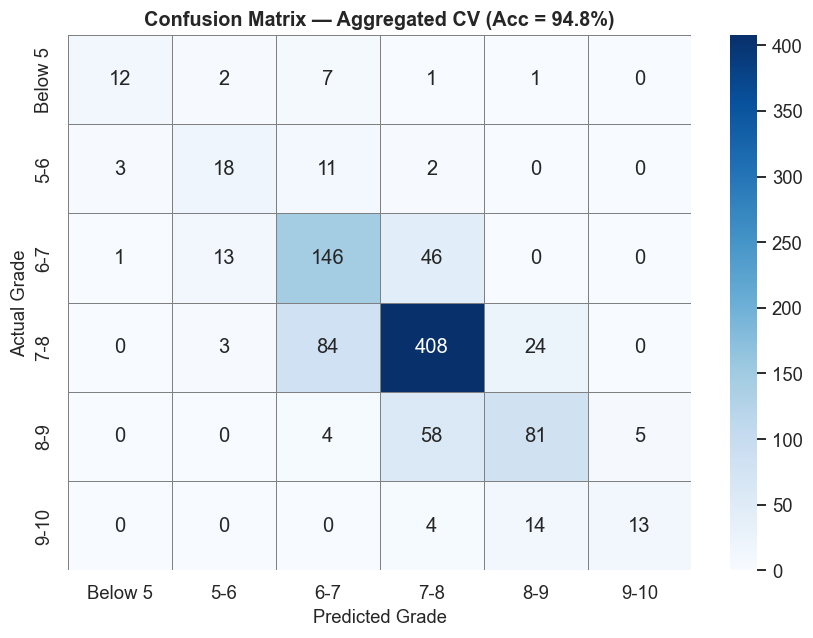


Per-Class Classification Report:
              precision    recall  f1-score   support

     Below 5       0.75      0.52      0.62        23
         5-6       0.50      0.53      0.51        34
         6-7       0.58      0.71      0.64       206
         7-8       0.79      0.79      0.79       519
         8-9       0.68      0.55      0.60       148
        9-10       0.72      0.42      0.53        31

    accuracy                           0.71       961
   macro avg       0.67      0.59      0.61       961
weighted avg       0.71      0.71      0.70       961



In [9]:
# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX — AVERAGE CV (All Folds Pooled)
# ══════════════════════════════════════════════════════════════
cm_agg_df = pd.DataFrame(
    cv_agg['cm'],
    index=[f'True: {l}' for l in GRADE_LABELS],
    columns=[f'Pred: {l}' for l in GRADE_LABELS]
)
print(f'Confusion Matrix — Aggregated 10-Fold CV (Acc = {cv_agg["acc_10"]}%)')
print()
display(cm_agg_df)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cv_agg['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=GRADE_LABELS, yticklabels=GRADE_LABELS, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted Grade', fontsize=12)
ax.set_ylabel('Actual Grade', fontsize=12)
ax.set_title(f'Confusion Matrix — Aggregated CV (Acc = {cv_agg["acc_10"]}%)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nPer-Class Classification Report:')
print(classification_report(cv_agg['g_true'], cv_agg['g_pred'],
                            labels=GRADE_LABELS, zero_division=0))

---
## 4. Metrics for HOLDOUT (80/20 Split)

In [10]:
print('=' * 65)
print('HOLDOUT EVALUATION (80/20 Split)')
print('=' * 65)
print(f'  Split Ratio         : 80% Train / 20% Test')
print(f'  Training Set Size   : {holdout["train_size"]} students')
print(f'  Test Set Size       : {holdout["val_size"]} students')
print(f'  ---')
print(f'  R\u00b2 (R-Squared)      : {holdout["r2"]}')
print(f'  MAE                 : {holdout["mae"]}')
print(f'  RMSE                : {holdout["rmse"]}')
print(f'  Accuracy (\u00b10.5)     : {holdout["acc_05"]}%')
print(f'  Accuracy (\u00b11.0)     : {holdout["acc_10"]}%')
print(f'  ---')
print(f'  Precision (weighted): {holdout["precision"]}')
print(f'  Recall (weighted)   : {holdout["recall"]}')
print(f'  F1 Score (weighted) : {holdout["f1"]}')

HOLDOUT EVALUATION (80/20 Split)
  Split Ratio         : 80% Train / 20% Test
  Training Set Size   : 768 students
  Test Set Size       : 193 students
  ---
  R² (R-Squared)      : 0.7788
  MAE                 : 0.3028
  RMSE                : 0.497
  Accuracy (±0.5)     : 78.8%
  Accuracy (±1.0)     : 94.3%
  ---
  Precision (weighted): 0.7293
  Recall (weighted)   : 0.7306
  F1 Score (weighted) : 0.719


Confusion Matrix — Holdout (Acc = 94.3%)



,Pred: Below 5,Pred: 5-6,Pred: 6-7,Pred: 7-8,Pred: 8-9,Pred: 9-10
True: Below 5,4,0,2,0,0,0
True: 5-6,1,3,4,1,0,0
True: 6-7,0,2,36,14,0,0
True: 7-8,0,0,8,83,4,0
True: 8-9,0,0,2,13,13,1
True: 9-10,0,0,0,0,0,2


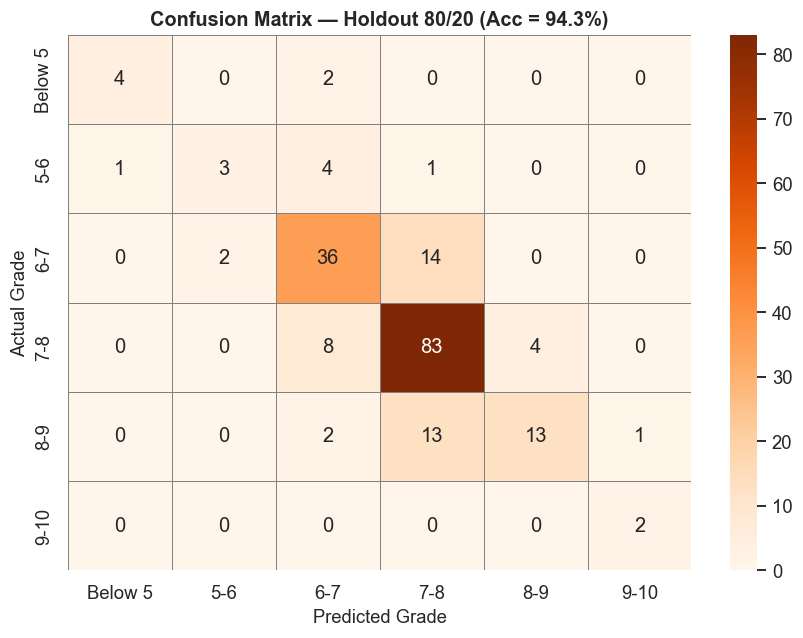


Per-Class Classification Report:
              precision    recall  f1-score   support

     Below 5       0.80      0.67      0.73         6
         5-6       0.60      0.33      0.43         9
         6-7       0.69      0.69      0.69        52
         7-8       0.75      0.87      0.81        95
         8-9       0.76      0.45      0.57        29
        9-10       0.67      1.00      0.80         2

    accuracy                           0.73       193
   macro avg       0.71      0.67      0.67       193
weighted avg       0.73      0.73      0.72       193



In [11]:
# ══════════════════════════════════════════════════════════════
# CONFUSION MATRIX — HOLDOUT (80/20)
# ══════════════════════════════════════════════════════════════
cm_h_df = pd.DataFrame(
    holdout['cm'],
    index=[f'True: {l}' for l in GRADE_LABELS],
    columns=[f'Pred: {l}' for l in GRADE_LABELS]
)
print(f'Confusion Matrix — Holdout (Acc = {holdout["acc_10"]}%)')
print()
display(cm_h_df)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(holdout['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=GRADE_LABELS, yticklabels=GRADE_LABELS, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted Grade', fontsize=12)
ax.set_ylabel('Actual Grade', fontsize=12)
ax.set_title(f'Confusion Matrix — Holdout 80/20 (Acc = {holdout["acc_10"]}%)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nPer-Class Classification Report:')
print(classification_report(holdout['g_true'], holdout['g_pred'],
                            labels=GRADE_LABELS, zero_division=0))

---
## 5. Side-by-Side Comparison Table

In [12]:
comparison = pd.DataFrame({
    'Metric': [
        'Split Ratio', 'Training Set Size', 'Test/Val Set Size',
        'R\u00b2', 'MAE', 'RMSE',
        'Accuracy (\u00b10.5)', 'Accuracy (\u00b11.0)',
        'Precision (weighted)', 'Recall (weighted)', 'F1 Score (weighted)'
    ],
    f'Best Fold (Fold {max_fold["fold"]})': [
        '90/10', max_fold['train_size'], max_fold['val_size'],
        max_fold['r2'], max_fold['mae'], max_fold['rmse'],
        f"{max_fold['acc_05']}%", f"{max_fold['acc_10']}%",
        max_fold['precision'], max_fold['recall'], max_fold['f1']
    ],
    'CV Average (10 Folds)': [
        '90/10 x 10', '~865 per fold', '~96 per fold',
        cv_agg['r2'], cv_agg['mae'], cv_agg['rmse'],
        f"{cv_agg['acc_05']}%", f"{cv_agg['acc_10']}%",
        cv_agg['precision'], cv_agg['recall'], cv_agg['f1']
    ],
    'Holdout (80/20)': [
        '80/20', holdout['train_size'], holdout['val_size'],
        holdout['r2'], holdout['mae'], holdout['rmse'],
        f"{holdout['acc_05']}%", f"{holdout['acc_10']}%",
        holdout['precision'], holdout['recall'], holdout['f1']
    ]
})

comparison = comparison.set_index('Metric')
comparison

,Best Fold (Fold 6),CV Average (10 Folds),Holdout (80/20)
Metric,,,
Split Ratio,90/10,90/10 x 10,80/20
Training Set Size,865,~865 per fold,768
Test/Val Set Size,96,~96 per fold,193
R²,0.8648,0.7459,0.7788
MAE,0.2414,0.2911,0.3028
RMSE,0.3708,0.501,0.497
Accuracy (±0.5),88.5%,82.1%,78.8%
Accuracy (±1.0),96.9%,94.8%,94.3%
Precision (weighted),0.7852,0.7116,0.7293


---
## 6. Visualization: Per-Fold Performance

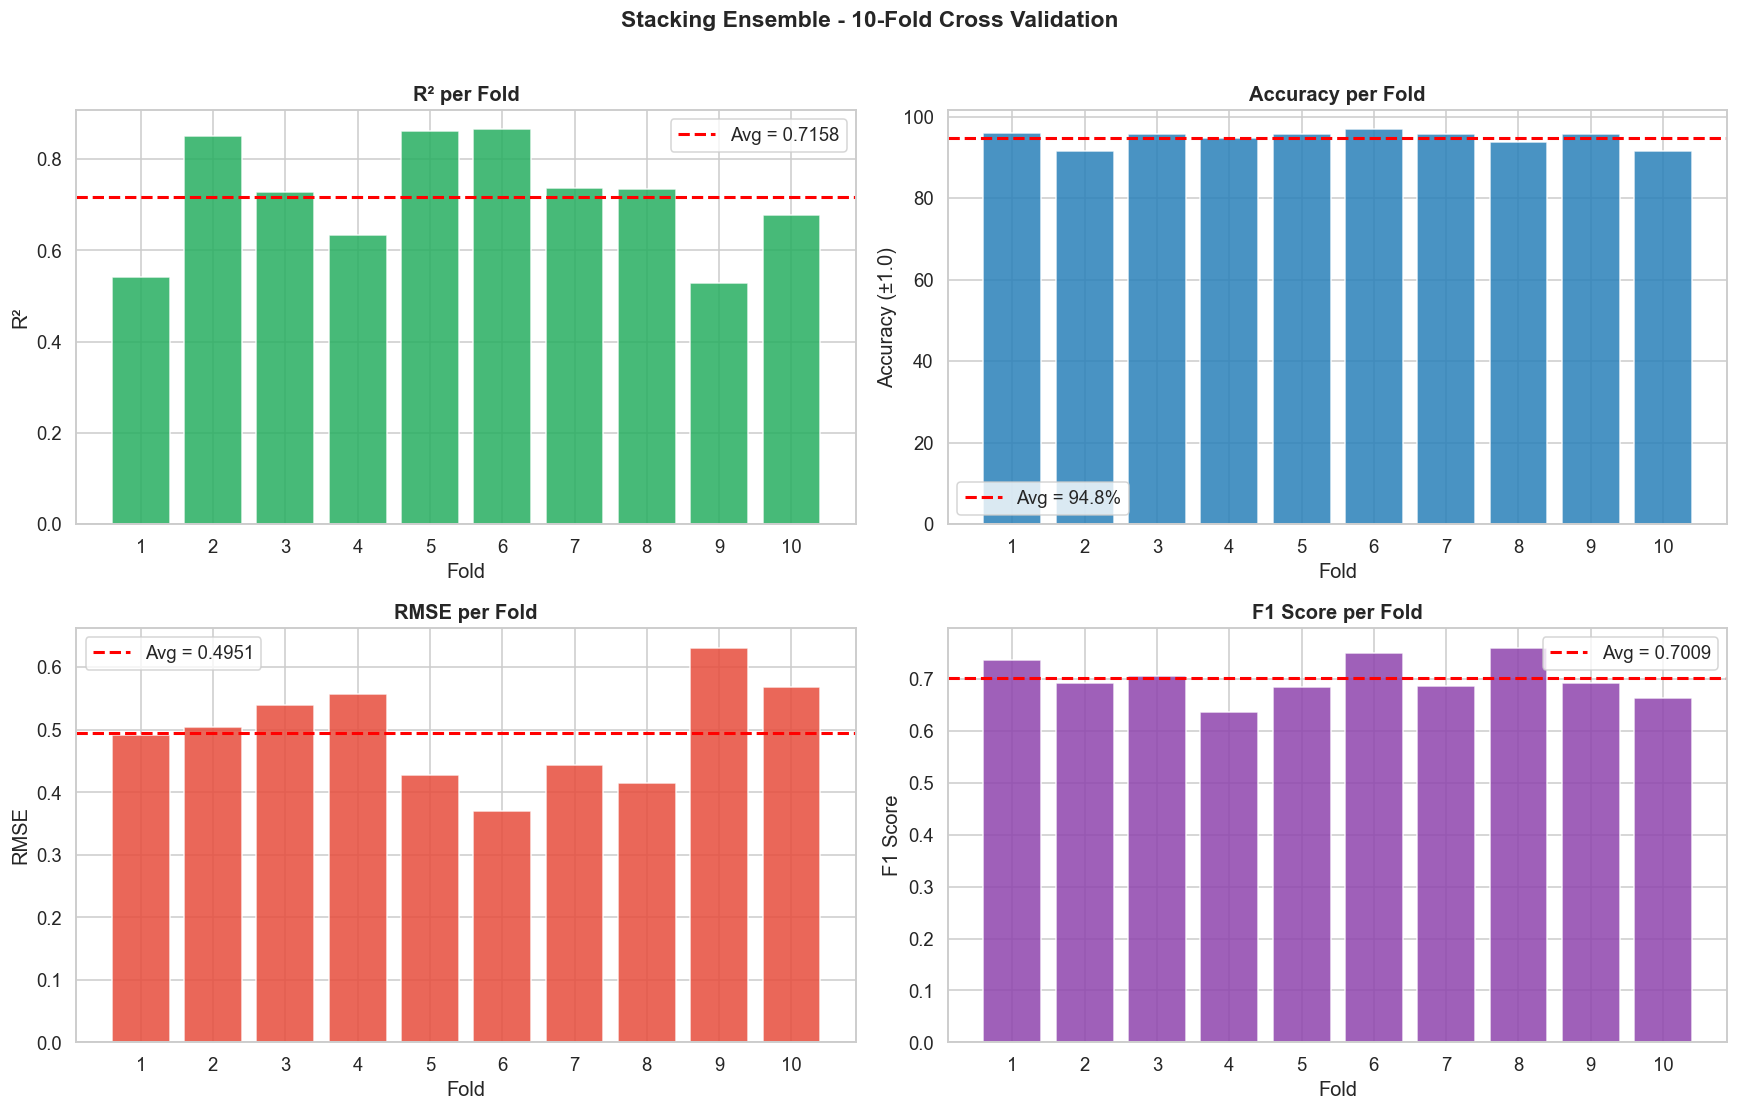

In [13]:
fold_nums = [m['fold'] for m in all_fold_metrics]
r2_vals   = [m['r2'] for m in all_fold_metrics]
acc_vals  = [m['acc_10'] for m in all_fold_metrics]
rmse_vals = [m['rmse'] for m in all_fold_metrics]
f1_vals   = [m['f1'] for m in all_fold_metrics]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# R2
axes[0,0].bar(fold_nums, r2_vals, color='#27ae60', alpha=0.85, edgecolor='white')
axes[0,0].axhline(np.mean(r2_vals), color='red', lw=2, ls='--', label=f'Avg = {np.mean(r2_vals):.4f}')
axes[0,0].set_xlabel('Fold'); axes[0,0].set_ylabel('R\u00b2')
axes[0,0].set_title('R\u00b2 per Fold', fontweight='bold'); axes[0,0].legend(); axes[0,0].set_xticks(fold_nums)

# Accuracy
axes[0,1].bar(fold_nums, acc_vals, color='#2980b9', alpha=0.85, edgecolor='white')
axes[0,1].axhline(np.mean(acc_vals), color='red', lw=2, ls='--', label=f'Avg = {np.mean(acc_vals):.1f}%')
axes[0,1].set_xlabel('Fold'); axes[0,1].set_ylabel('Accuracy (\u00b11.0)')
axes[0,1].set_title('Accuracy per Fold', fontweight='bold'); axes[0,1].legend(); axes[0,1].set_xticks(fold_nums)

# RMSE
axes[1,0].bar(fold_nums, rmse_vals, color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1,0].axhline(np.mean(rmse_vals), color='red', lw=2, ls='--', label=f'Avg = {np.mean(rmse_vals):.4f}')
axes[1,0].set_xlabel('Fold'); axes[1,0].set_ylabel('RMSE')
axes[1,0].set_title('RMSE per Fold', fontweight='bold'); axes[1,0].legend(); axes[1,0].set_xticks(fold_nums)

# F1
axes[1,1].bar(fold_nums, f1_vals, color='#8e44ad', alpha=0.85, edgecolor='white')
axes[1,1].axhline(np.mean(f1_vals), color='red', lw=2, ls='--', label=f'Avg = {np.mean(f1_vals):.4f}')
axes[1,1].set_xlabel('Fold'); axes[1,1].set_ylabel('F1 Score')
axes[1,1].set_title('F1 Score per Fold', fontweight='bold'); axes[1,1].legend(); axes[1,1].set_xticks(fold_nums)

plt.suptitle('Stacking Ensemble - 10-Fold Cross Validation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()